### Data importation and cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\HomePC\\Downloads\\TB_outcomes_age_sex_2026-07-03.csv",
             index_col='country', 
            names=['country','iso2','iso3','iso_numceric','WHO_region','year','cohort_type',
                     'age_group','sex','total_patients_cohort','success','failure','deaths',
                     'lost_to_follow_up','not_evaluated','success_rate'])

df = df.drop(labels='country', axis=0)

sex_full = []
for data in df['sex']:
    if data == 'f':
        sex_full.append('Female')
    elif data == 'm':
        sex_full.append('Male')
    elif data == 'a':
        sex_full.append('All sexes')

df['sex'] = sex_full


ages= []

for age in df['age_group']:
    if age == 'a':
        ages.append('All ages')
    else:
        ages.append(age)


df['age_group'] = ages


df['total_patients_cohort'] = pd.to_numeric(df['total_patients_cohort'], errors='coerce')
df['success'] = pd.to_numeric(df['success'], errors='coerce')
df['failure'] = pd.to_numeric(df['failure'], errors='coerce')
df['deaths'] = pd.to_numeric(df['deaths'], errors='coerce')
df['lost_to_follow_up'] = pd.to_numeric(df['lost_to_follow_up'], errors='coerce')
df['not_evaluated'] = pd.to_numeric(df['total_patients_cohort'], errors='coerce')
df['success_rate'] = pd.to_numeric(df['success_rate'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [38]:
df

,iso2,iso3,iso_numceric,WHO_region,year,cohort_type,age_group,sex,total_patients_cohort,success,failure,deaths,lost_to_follow_up,not_evaluated,success_rate
country,,,,,,,,,,,,,,,
Afghanistan,AF,AFG,004,EMR,2018,newrel,0-14,All sexes,10461,10027.0,NaN,NaN,NaN,10461,96.0
Albania,AL,ALB,008,EUR,2010,newrel,0-14,All sexes,18,17.0,0.0,0.0,0.0,18,94.0
Albania,AL,ALB,008,EUR,2011,newrel,0-14,All sexes,7,7.0,0.0,0.0,0.0,7,100.0
Albania,AL,ALB,008,EUR,2012,newrel,0-14,All sexes,3,3.0,0.0,0.0,0.0,3,100.0
Albania,AL,ALB,008,EUR,2013,newrel,0-14,All sexes,19,18.0,0.0,0.0,1.0,19,95.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zimbabwe,ZW,ZWE,716,AFR,2021,newrel,All ages,Male,10475,9535.0,71.0,637.0,82.0,10475,91.0
Zimbabwe,ZW,ZWE,716,AFR,2022,newrel,0-14,All sexes,1109,1082.0,NaN,NaN,NaN,1109,98.0
Zimbabwe,ZW,ZWE,716,AFR,2023,newrel,0-14,All sexes,1136,1061.0,NaN,NaN,NaN,1136,93.0


### Yearly Number of patients who were successfully treated

In [88]:


tb_success = df[df['success'].notna()].groupby(['year'])['success'].sum().sort_values(ascending=False).reset_index()


In [89]:
tb_success

,year,success
0,2023,5393366.0
1,2022,4926688.0
2,2019,4510819.0
3,2021,4293380.0
4,2020,3770155.0
5,2018,327552.0
6,2014,13968.0
7,2016,13609.0
8,2013,13256.0
9,2015,12628.0


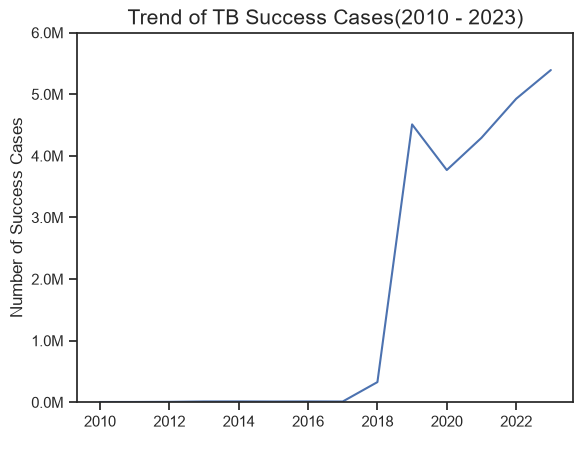

In [104]:
fig, ax = plt.subplots()
sns.set_theme(style='ticks')
sns.lineplot(
    data=tb_success,
    x='year',
    y='success',
    legend=False,
    ax=ax
)

plt.ylim(0,6000000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1000000:.1f}M'))
plt.title('Trend of TB Success Cases(2010 - 2023)', fontsize=15)
plt.xlabel(' ')
plt.ylabel('Number of Success Cases')
plt.show()


### Yearly Number of patients whose treatment were not successful

In [98]:
tb_failure = df[df['failure'].notna()].groupby(['year'])['failure'].sum().sort_values(ascending=False).reset_index()


In [99]:
tb_failure

,year,failure
0,2021,25281.0
1,2023,24655.0
2,2019,24527.0
3,2022,21467.0
4,2020,19559.0
5,2013,166.0
6,2010,131.0
7,2016,84.0
8,2015,73.0
9,2014,72.0


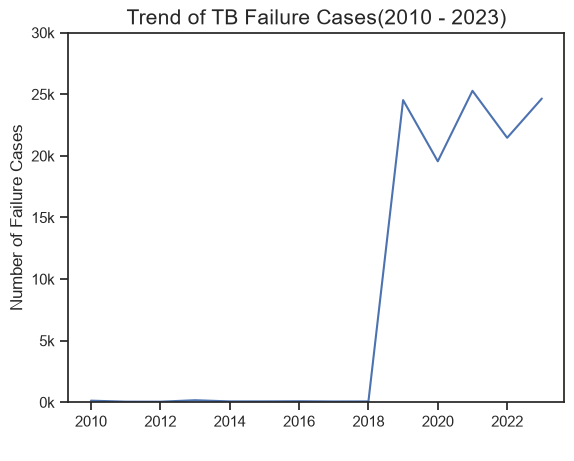

In [160]:
fig, ax = plt.subplots()
sns.set_theme(style='ticks')
sns.lineplot(
    data=tb_failure,
    x='year',
    y='failure',
    legend=False,
    ax=ax
)

plt.ylim(0,30000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1000:.0f}k'))
plt.title('Trend of TB Failure Cases(2010 - 2023)', fontsize=15)
plt.xlabel(' ')
plt.ylabel('Number of Failure Cases')
plt.show()

### Top 5 Countries with  Highest TB deaths within the period TB most occured (2021-2023)

In [121]:
tb_deaths = df.pivot_table(index=df.index, columns='year', values='deaths', aggfunc='sum')
tb_deaths['total'] = tb_deaths.sum(axis=1)
tb_deaths.sort_values(by='total', ascending=False, inplace=True)

tb_deaths.drop(columns='total', inplace=True)


In [157]:
tb_deaths.loc['total'] = tb_deaths.sum(axis=0)
tb_deaths.sort_values(by='total', ascending=False,axis=1,inplace=True)
tb_most_deaths = tb_deaths.iloc[0:5,0:3]
tb_most_deaths

year,2023,2022,2021
country,,,
India,86627.0,89764.0,88028.0
Indonesia,26955.0,22585.0,15196.0
China,15664.0,13895.0,13527.0
South Africa,9449.0,14626.0,12861.0
Philippines,10073.0,9353.0,7850.0


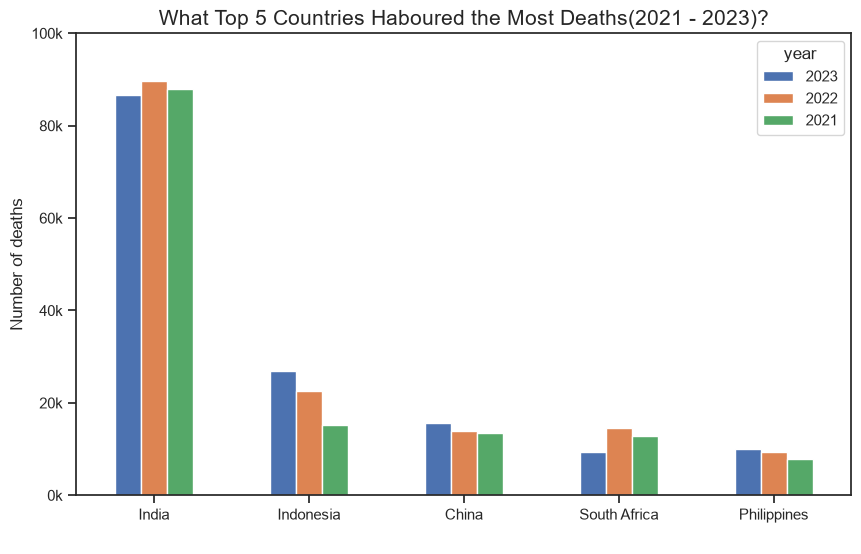

In [172]:
fig, ax = plt.subplots()

tb_most_deaths.plot(kind='bar', figsize=(10,6), ax=ax)

plt.ylim(0,100000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1000:.0f}k'))
plt.title('What Top 5 Countries Haboured the Most Deaths(2021 - 2023)?', fontsize=15)
plt.xlabel(' ')
plt.xticks(rotation=360, ha='center')
plt.ylabel('Number of deaths')
plt.show()